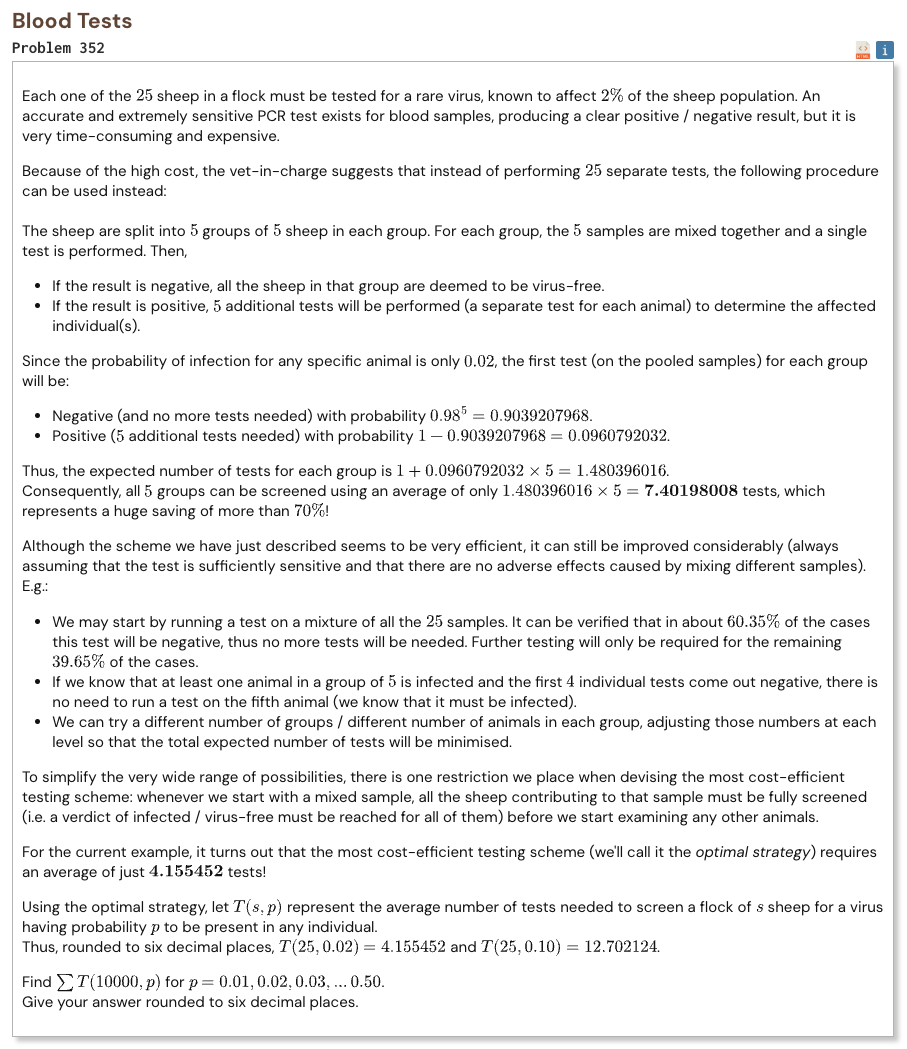

## Initial approach

* use two states for each group size
* one state means we know nothing about the group
* the other state means the group is known to contain at least one infected sheep
* for an unknown group, either test individually, split into smaller groups, or test the whole group first
* for a known-positive group, test a subgroup and branch on positive or negative result
* dynamic programming keeps the cheapest expected value for every size
* floating point is enough because the answer is rounded to six decimals

In [1]:
def T(n, p):
    q = 1.0 - p
    q_power = [1.0] * (n + 1)

    for i in range(1, n + 1):
        q_power[i] = q_power[i - 1] * q

    unknown = [0.0] * (n + 1)
    positive = [0.0] * (n + 1)

    unknown[1] = 1.0
    positive[1] = 0.0

    for size in range(2, n + 1):
        best_positive = size - 1.0
        denominator = 1.0 - q_power[size]

        for first in range(1, size):
            probability_negative = (q_power[first] - q_power[size]) / denominator
            probability_positive = (1.0 - q_power[first]) / denominator

            value = 1.0
            value += probability_negative * positive[size - first]
            value += probability_positive * (positive[first] + unknown[size - first])

            if value < best_positive:
                best_positive = value

        positive[size] = best_positive

        best_unknown = float(size)

        for first in range(1, size // 2 + 1):
            value = unknown[first] + unknown[size - first]

            if value < best_unknown:
                best_unknown = value

        pooled_value = 1.0 + (1.0 - q_power[size]) * positive[size]

        if pooled_value < best_unknown:
            best_unknown = pooled_value

        unknown[size] = best_unknown

    return unknown[n]

assert round(T(25, 0.02), 6) == 3.922183

In [2]:
%%time
result = T(10000, 0.01)
print("Result:", f"{result:.6f}")

Result: 917.704959
CPU times: user 6.74 s, sys: 25 ms, total: 6.76 s
Wall time: 6.76 s
